# Bob's burger

In [ ]:
#setup
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib import colors
from pypalettes import load_cmap

In [2]:
#load data
transcripts = pd.read_csv("Transcript_Bobs_Burgers_Data_Clean.csv")
imdb_wiki = pd.read_csv("IMDb_Wikipedia_Bobs_Burgers_Data_Clean.csv")
imdb_wiki.head()

,episode_overall,imdb_aired_date,year,season,episode,imdb_title,rating,synopsis,wikipedia_directed_by,wikipedia_written_by,wikipedia_viewers
0,1,2011-01-08,2011,1,1,Human Flesh,7.7,On top of watching his dysfunctional family cr...,Anthony Chun,Loren Bouchard & Jim Dauterive,9.38
1,2,2011-01-15,2011,1,2,Crawl Space,8.1,"His in-laws are coming into town, and Bob trie...",Kyounghee Lim,Loren Bouchard & Jim Dauterive,5.07
2,3,2011-01-22,2011,1,3,Sacred Cow,7.5,A filmmaker placed a cow outside the restauran...,Jennifer Coyle,Nora Smith,4.81
3,4,2011-02-12,2011,1,4,Sexy Dance Fighting,7.4,When Tina develops a crush on the new martial ...,Anthony Chun,Steven Davis & Kelvin Yu,4.19
4,5,2011-02-19,2011,1,5,Hamburger Dinner Theater,7.5,Linda is dying to relive her dream of becoming...,Wes Archer,Dan Fybel & Rich Rinaldi,4.87


In [3]:
transcripts.head()

,season,episode,title,line,raw_text,dialogue
0,1,1,Human Flesh,1,NaN,NaN
1,1,1,Human Flesh,2,NaN,NaN
2,1,1,Human Flesh,3,NaN,NaN
3,1,1,Human Flesh,4,"Listen, pep talk.","Listen, pep talk."
4,1,1,Human Flesh,5,Big day today.,Big day today.


In [ ]:
#count names and words
transcripts["fart"] = transcripts["raw_text"].str.lower().str.count("fart")
transcripts["butt"] = transcripts["raw_text"].str.lower().str.count("butt")
transcripts["Jimmy"] = transcripts["raw_text"].str.count("Jimmy")
transcripts["Gene"] = transcripts["raw_text"].str.count("Gene")
transcripts["Tina"] = transcripts["raw_text"].str.count("Tina")
transcripts["Bob"] = transcripts["raw_text"].str.count("Bob")
transcripts["Bobby"] = transcripts["raw_text"].str.count("Bobby")
transcripts["Linda"] = transcripts["raw_text"].str.count("Linda")
transcripts["Louise"] = transcripts["raw_text"].str.count("Louise")

#merge word counts with df
strings_df = transcripts.groupby([ "season", "episode"]).agg({"butt": "sum", "fart":"sum", "Jimmy": "sum",
                                                               "Gene": "sum", "Bob": "sum","Bobby": "sum",  "Tina": "sum",
                                                                "Louise": "sum",  "Linda": "sum"}).reset_index()
df = pd.merge(imdb_wiki, strings_df, left_on=["season", "episode"], right_on=["season", "episode"], how="left")
df["id"] = df["season"].astype(str) +"-"+ df["episode"].astype(str)
df.head()

## Data viz

In [108]:
pivot = df.groupby(["season", "episode"])[["Bob","Tina","Gene",  "Louise","Linda", "fart" , "butt"]].sum().reset_index()
pivot["last_episode"] = 0
for i in range(0,len(pivot)-1):
    if pivot["season"].iloc[i] != pivot["season"].iloc[i+1]:
        pivot["last_episode"].iloc[i] = 1

# Find indices of last episodes
indices = pivot.index[pivot['last_episode'] == 1].tolist()

# Create empty rows (NaN-filled)
empty_rows = pd.DataFrame([[None] * len(pivot.columns)] * 2, columns=pivot.columns)

# Loop through indices in reverse order to avoid index shift
for idx in reversed(indices):
    pivot = pd.concat([pivot.iloc[:idx+1], empty_rows, pivot.iloc[idx+1:]]).reset_index(drop=True)

pivot = pivot.transpose().fillna(-1)

C:\Users\LISA~1.HOR\AppData\Local\Temp/ipykernel_23176/3083051478.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pivot["last_episode"].iloc[i] = 1
C:\Users\LISA~1.HOR\AppData\Local\Temp/ipykernel_23176/3083051478.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pivot["last_episode"].iloc[i] = 1
C:\Users\LISA~1.HOR\AppData\Local\Temp/ipykernel_23176/3083051478.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pivot["last_episo

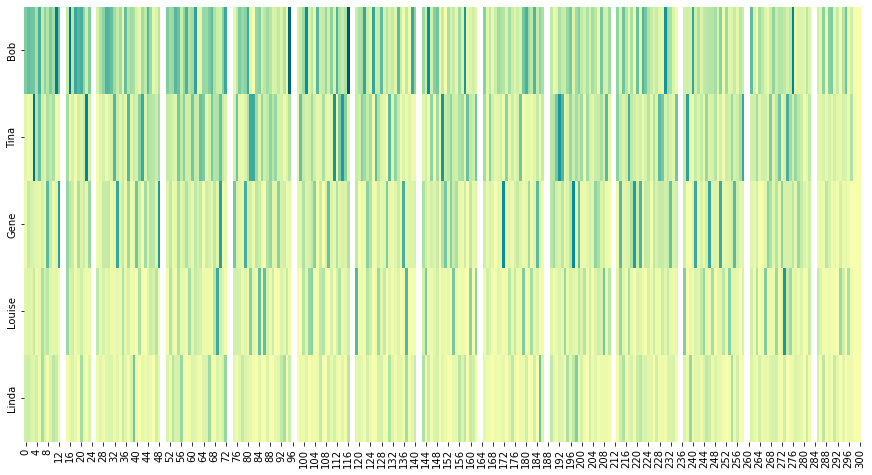

In [107]:
# amend colour palette so that -1 = given background colour
def get_colormap(hex_colors, bg_color, value_range):
    listed_colormap = colors.LinearSegmentedColormap.from_list('colorpalette', hex_colors, N=value_range) 
    bg_color = np.array(colors.to_rgba(bg_color))
    newcolors = listed_colormap(np.linspace(0, 1, value_range))
    cmap_new = colors.ListedColormap(np.vstack((bg_color, newcolors)))
    return cmap_new

value_range = int(max(pivot.max()+1))
bg_color = '#FFFFFF'
hex_colors = load_cmap("BluYl").colors

cmap = get_colormap(hex_colors, bg_color, value_range)

data = pivot[pivot.index.isin(["Bob", "Linda", "Tina", "Gene", "Louise"])]

fig, ax = plt.subplots(figsize=(15,8))
sns.heatmap(data, annot=False, fmt=".2f", cmap=cmap, linewidths=0, ax=ax, cbar=False)
plt.show()

## Explore

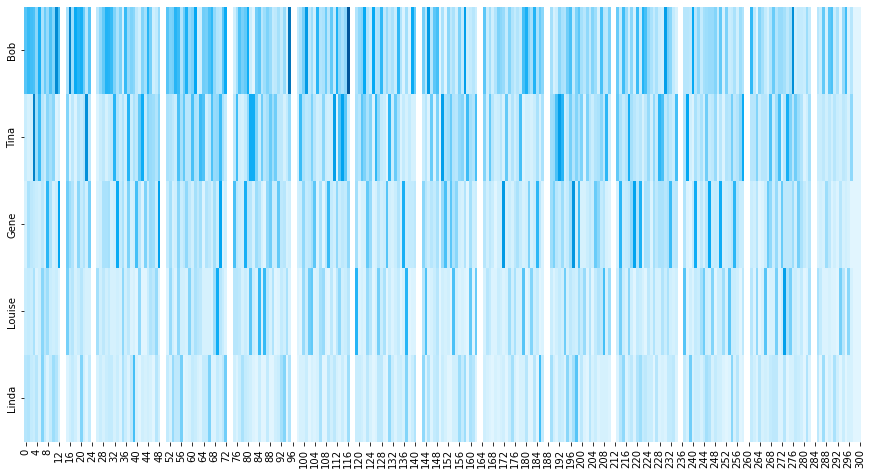

In [102]:
# amend colour palette so that -1 = given background colour
def get_colormap(hex_colors, bg_color, value_range):
    listed_colormap = colors.LinearSegmentedColormap.from_list('colorpalette', hex_colors, N=value_range) 
    bg_color = np.array(colors.to_rgba(bg_color))
    newcolors = listed_colormap(np.linspace(0, 1, value_range))
    cmap_new = colors.ListedColormap(np.vstack((bg_color, newcolors)))
    return cmap_new

value_range = int(max(pivot.max()+1))
bg_color = '#FFFFFF'
hex_colors = load_cmap("light_blue_material").colors
cmap = get_colormap(hex_colors, bg_color, value_range)

#plot data
data = pivot.iloc[:-2]

fig, ax = plt.subplots(figsize=(15,8))
sns.heatmap(data, annot=False, cmap=cmap, linewidths=0, ax=ax, cbar=False)
plt.show()

In [ ]:
pivot = df.groupby(["season", "episode"])[["Bob","Tina","Gene",  "Louise","Linda", "fart" , "butt"]].sum().reset_index()
#pivot["row"] = 1
#pivot = pivot.drop(columns="id").set_index("row").transpose()

pivot["pos"] = 0
for i in range(1,len(pivot)):
    if pivot["season"].iloc[i] == pivot["season"].iloc[i-1]:
        pivot["pos"].iloc[i] = pivot["pos"].iloc[i-1] + 1
    else:
        pivot["pos"].iloc[i] = pivot["pos"].iloc[i-1] + 3
    
pivot = pivot.drop(columns=["season", "episode"]).set_index("pos").transpose()

In [74]:
df.groupby("season")["episode"].count()

season
1     13
2      9
3     23
4     22
5     21
6     19
7     22
8     20
9     22
10    22
11    22
12    22
13    22
14    16
Name: episode, dtype: int64

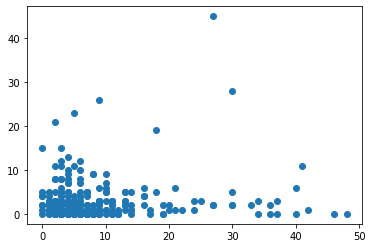

In [67]:
#fart vs ratings
plt.scatter(df["Gene"], df["butt"])

c:\Users\lisa.hornung\anaconda3\envs\py3_viz\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='Linda', ylabel='rating'>

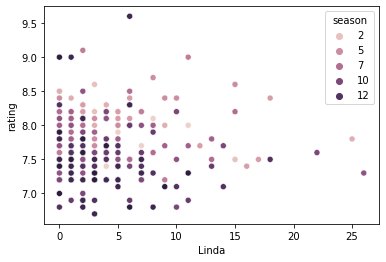

In [81]:
#fart vs ratings
sns.scatterplot(df["Linda"], df["rating"],hue=df["season"])

c:\Users\lisa.hornung\anaconda3\envs\py3_viz\lib\site-packages\seaborn\categorical.py:1296: UserWarning: 28.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\lisa.hornung\anaconda3\envs\py3_viz\lib\site-packages\seaborn\categorical.py:1296: UserWarning: 5.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\lisa.hornung\anaconda3\envs\py3_viz\lib\site-packages\seaborn\categorical.py:1296: UserWarning: 11.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\lisa.hornung\anaconda3\envs\py3_viz\lib\site-packages\seaborn\categorical.py:1296: UserWarning: 18.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\lisa.hornung\ana

<AxesSubplot:xlabel='season', ylabel='butt'>

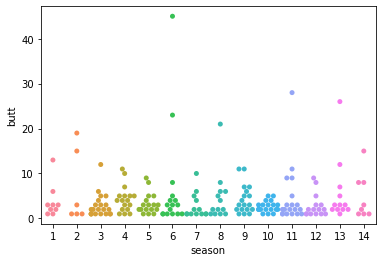

In [97]:
pivot = df[df["butt"]!=0]
sns.swarmplot(y=pivot["butt"],x=pivot["season"])

In [179]:
df[["Bob", "Linda", "Tina", "Louise", "Gene"]].sum()

Bob       3917.0
Linda     1145.0
Tina      2969.0
Louise    1607.0
Gene      2318.0
dtype: float64

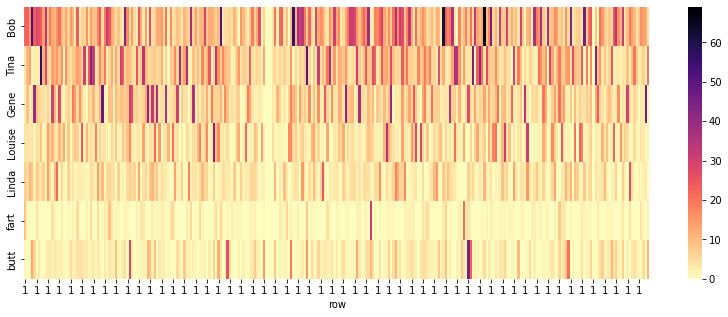

In [180]:
fig, ax = plt.subplots(figsize=(14,5))
sns.heatmap(pivot, annot=False, fmt=".2f", cmap="magma_r", linewidths=0, ax=ax)
plt.show()

In [197]:
pivot = df.groupby("id")[[ "fart" , "butt"]].sum().reset_index()
#pivot["row"] = 1
pivot = pivot.drop(columns="id")
#.set_index("row").transpose()
pivot

,fart,butt
0,9.0,1.0
1,1.0,0.0
2,0.0,1.0
3,0.0,13.0
4,0.0,6.0
...,...,...
270,0.0,1.0
271,4.0,0.0
272,1.0,5.0
273,0.0,0.0


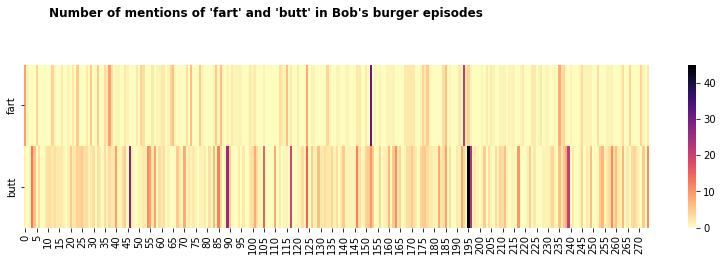

In [202]:
pivot = df.groupby("id")[[ "fart" , "butt"]].sum().reset_index()
pivot["row"] = 1
pivot = pivot.drop(columns="id").set_index("row").transpose()

pivot = df.groupby("id")[[ "fart" , "butt"]].sum().reset_index()
#pivot["row"] = 1
pivot = pivot.drop(columns="id").transpose()

fig, ax = plt.subplots(figsize=(14,3))
sns.heatmap(pivot, annot=False, fmt=".2f", cmap="magma_r", linewidths=0, ax=ax)

fig.set_facecolor("white")
plt.figtext(0.15,1.1, "Number of mentions of 'fart' and 'butt' in Bob's burger episodes", fontsize=12, fontweight="bold", ha="left")
plt.show()

<AxesSubplot:xlabel='episode', ylabel='season'>

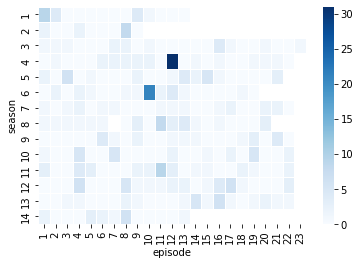

In [112]:
sns.heatmap(df.pivot(index="season", columns="episode", values="fart"), annot=False, fmt=".2f", cmap="Blues", linewidths=0.5)


In [ ]:
sns.heatmap(df.pivot(index="season", columns="episode", values="fart"), annot=False, fmt=".2f", cmap="Blues", linewidths=0.5)

In [117]:
df.pivot(index="season", columns="episode", values="Linda")

episode,1,2,3,4,5,6,7,8,9,10,...,14,15,16,17,18,19,20,21,22,23
season,,,,,,,,,,,,,,,,,,,,,
1,7.0,8.0,5.0,4.0,7.0,2.0,15.0,5.0,1.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.0,3.0,5.0,3.0,0.0,15.0,3.0,0.0,5.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2.0,4.0,2.0,4.0,5.0,5.0,2.0,4.0,1.0,9.0,...,25.0,2.0,0.0,3.0,2.0,3.0,2.0,0.0,7.0,3.0
4,5.0,2.0,12.0,6.0,6.0,17.0,0.0,1.0,2.0,5.0,...,5.0,5.0,16.0,1.0,1.0,5.0,3.0,6.0,18.0,NaN
5,3.0,1.0,4.0,9.0,5.0,4.0,3.0,1.0,0.0,4.0,...,0.0,0.0,3.0,4.0,10.0,15.0,0.0,8.0,NaN,NaN
6,0.0,2.0,2.0,4.0,0.0,2.0,1.0,2.0,9.0,0.0,...,6.0,2.0,1.0,4.0,1.0,11.0,NaN,NaN,NaN,NaN
7,4.0,4.0,3.0,1.0,6.0,2.0,0.0,1.0,6.0,6.0,...,4.0,1.0,4.0,4.0,2.0,15.0,1.0,4.0,8.0,NaN
8,13.0,1.0,8.0,1.0,5.0,6.0,NaN,4.0,2.0,0.0,...,11.0,5.0,11.0,0.0,9.0,7.0,1.0,NaN,NaN,NaN
9,3.0,2.0,1.0,0.0,2.0,1.0,2.0,3.0,0.0,4.0,...,2.0,2.0,7.0,0.0,0.0,7.0,0.0,26.0,5.0,NaN


In [ ]:
df[["Linda", "season"]]

0    Linda      7.0
     season     1.0
1    Linda      8.0
     season     1.0
2    Linda      5.0
               ... 
271  Linda      2.0
     season    14.0
272  season    14.0
273  season    14.0
274  season    14.0
Length: 546, dtype: float64

c:\Users\lisa.hornung\anaconda3\envs\py3_viz\lib\site-packages\seaborn\categorical.py:1296: UserWarning: 17.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\lisa.hornung\anaconda3\envs\py3_viz\lib\site-packages\seaborn\categorical.py:1296: UserWarning: 13.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\lisa.hornung\anaconda3\envs\py3_viz\lib\site-packages\seaborn\categorical.py:1296: UserWarning: 19.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\lisa.hornung\anaconda3\envs\py3_viz\lib\site-packages\seaborn\categorical.py:1296: UserWarning: 15.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
c:\Users\lisa.hornung\an

<AxesSubplot:xlabel='season', ylabel='Linda'>

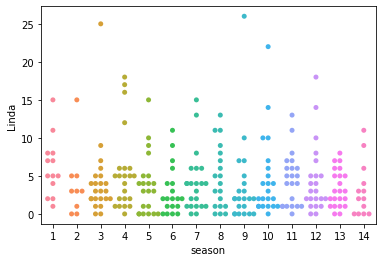

In [93]:
sns.swarmplot(y=df["Linda"],x=df["season"])

In [12]:
transcripts.groupby(["episode", "season"])["count_fart"].sum().unstack()

season,1,2,3,4,5,6,7,8,9,10,11,12,13,14
episode,,,,,,,,,,,,,,
1,9.0,2.0,1.0,0.0,2.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,2.0
2,4.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,1.0,0.0,5.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,1.0,0.0,0.0,0.0,2.0,2.0,1.0,0.0,5.0,4.0,6.0,1.0,0.0
5,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,2.0
6,0.0,0.0,0.0,2.0,0.0,0.0,1.0,1.0,4.0,0.0,0.0,0.0,0.0,1.0
7,0.0,0.0,1.0,0.0,0.0,0.0,1.0,NaN,1.0,0.0,0.0,0.0,0.0,1.0
8,0.0,7.0,2.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,4.0,2.0,2.0
9,4.0,0.0,0.0,2.0,2.0,0.0,0.0,3.0,2.0,0.0,2.0,1.0,1.0,0.0
